#### Imports

In [1]:
# Clone GitHub repository
!git clone https://github.com/tsnow2010/DATA_606.git

# Basic Packages
import os
import pandas as pd

# Import src files from GitHub
os.chdir("DATA_606/src")
import triage_xgb as t_xgb
os.chdir("..")

# Mount Google Drive
from google.colab import drive

# ML Packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

import xgboost as xgb

Cloning into 'DATA_606'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 58 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 319.47 KiB | 3.43 MiB/s, done.
Resolving deltas: 100% (17/17), done.


#### Mount Google Drive

In [5]:
drive.mount('/content/drive')

os.chdir('/content/drive/My Drive/DATA_606/Project_Folder/Triage_Functionality')

Mounted at /content/drive


#### EDA

In [ ]:
!ls /content/drive/MyDrive

'Battle of Antietam - Staff Ride - Final Assault.gdoc'
'Blue Jay Invitation COA1-COA2-COA3_1APR Feedback.gdoc'
'Blue Jay Invitation COA1-COA2-COA3_1APR Feedback.pdf'
'Colab Notebooks'
'DATA_603 Project Code Files'
 DATA_606
'DATA 606_Gantt Chart.xlsx'
'Dietary Restrictions.gform'
'iTAK Server Packages'
'Lab 1: Land Navigation Quiz (CST-Ready).gform'
'Lab 1: Land Navigation Quiz (Easier).gform'
'Meeting Reports'
'Meet Recordings'
 Points
 Shortcuts
'TAK Registration Questions.gform'
'UTP Midterm'


In [6]:
!cp "/content/drive/MyDrive/Copy of Yale_Dataset_Filtered.csv" Yale_Dataset_Filtered.csv

cp: cannot stat '/content/drive/MyDrive/Copy of Yale_Dataset_Filtered.csv': No such file or directory


In [7]:
# Sample original, filtered Yale School of Medicine dataset
df = pd.read_csv('Yale_Dataset_Filtered.csv', nrows=2)
df

,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,40,Male,Hispanic or Latino,White or Caucasian,English,NaN,Single,Full Time,Other,Discharge,...,0,0,0,0,0,0,0,0,0,0
1,66,Male,Hispanic or Latino,Native Hawaiian or Other Pacific Islander,English,Pentecostal,Married,Not Employed,Commercial,Discharge,...,0,0,0,0,0,0,0,0,0,0


### 1. Data Cleaning
> 1. Create dict for downcasted data types, e.g. Int64 to Int8, where feasible to reduce computing demand.
> 2. Replace NaN or delete rows with NaN.  Then, downgrade data types.


#### 1.1 - Create dict for downcasted data types

In [8]:
# Original feature data types and convert to dict.
dtypes_dict = dict(df.dtypes)
dtypes_dict.pop("disposition", None) # remove from dict to prevent error later
dtypes_dict # de-comment to see dict

{'age': dtype('int64'),
 'gender': dtype('O'),
 'ethnicity': dtype('O'),
 'race': dtype('O'),
 'lang': dtype('O'),
 'religion': dtype('O'),
 'maritalstatus': dtype('O'),
 'employstatus': dtype('O'),
 'insurance_status': dtype('O'),
 'previousdispo': dtype('O'),
 'triage_vital_hr': dtype('int64'),
 'triage_vital_sbp': dtype('int64'),
 'triage_vital_dbp': dtype('int64'),
 'triage_vital_rr': dtype('int64'),
 'triage_vital_o2': dtype('float64'),
 'triage_vital_temp': dtype('int64'),
 'n_surgeries': dtype('int64'),
 'n_edvisits': dtype('int64'),
 'n_admissions': dtype('int64'),
 'cc_abdominalcramping': dtype('int64'),
 'cc_abdominaldistention': dtype('int64'),
 'cc_abdominalpain': dtype('int64'),
 'cc_abdominalpainpregnant': dtype('int64'),
 'cc_abnormallab': dtype('int64'),
 'cc_abscess': dtype('int64'),
 'cc_addictionproblem': dtype('int64'),
 'cc_agitation': dtype('int64'),
 'cc_alcoholintoxication': dtype('int64'),
 'cc_alcoholproblem': dtype('int64'),
 'cc_allergicreaction': dtype('int

In [9]:
## Change feature data types via dict.

# Various features
cc_features = []
triage_features = []
for key in dtypes_dict:
  if key[0:3] == "cc_":
    cc_features.append(key) # make list of chief complaint (cc) features
    dtypes_dict[key] = "bool"
  elif key[0:2] == "n_":
    dtypes_dict[key] = "int32"
  elif key[0:7] == "triage_":
    triage_features.append(key)
    dtypes_dict[key] = "float64"


# Categorical features (remove, once the chunks go into .csv, this is dtype is lost anyways)
#for key in ['gender','ethnicity','race','lang','religion','maritalstatus','employstatus','insurance_status','disposition','previousdispo']:
#  dtypes_dict[key] = 'category'

# Age feature
dtypes_dict['age'] = 'int8'

#dtypes_dict

#### 1.2 - Remove NaN values and downcast data types (dtypes)
 - Many records contain NaN in "cc_" features.  
 - Will replace NaN with 0/False.
 - Had to utilize chunking for processing.

In [10]:
# Check if clean file exists, remove if it does
filename = "Yale_Dataset_Filtered_Clean.csv"

if os.path.exists(filename):
    os.remove(filename)

# Chunk, downgrade data type, and fill records with NaN in "cc_" features.

chunksize = 100_000
first = True
total_rows = 0

for i, chunk in enumerate(pd.read_csv("Yale_Dataset_Filtered.csv", chunksize=chunksize)):
  # Count rows in each chunk
  print(f"Chunk {i}: {len(chunk)} rows")
  total_rows += len(chunk)

  # Rename "disposition" to "discharge":bool.  True for discharge, false for admission
  chunk.rename(columns={'disposition': 'discharge'}, inplace=True)
  chunk['discharge'] = chunk['discharge'] \
  .apply(lambda x: True if x == 'Discharge' else False) \
  .astype('bool')

  # Fill/drop NaN and downcast dtypes
  for col, dtype in dtypes_dict.items():
    if col in cc_features:
      chunk[col] = chunk[col].fillna(0) # Replace NaN with 0/False
    elif col == 'religion':
      chunk[col] = chunk[col].fillna('Unknown') # Replace NaN with 'Unknown'
    elif col == 'age':
      chunk.dropna(subset=['age'], inplace=True) # Drop records
    elif col in triage_features: # NaN in these values can throw off results
      chunk.dropna(subset=[col], inplace=True) # Drop records

    chunk[col] = chunk[col].astype(dtype) # Change data types in df

  # Write cleaned chunk to disk immediately
  chunk.to_csv(filename, mode="a", header=first, index=False)
  first = False

print("Total rows:", total_rows)

Chunk 0: 100000 rows
Chunk 1: 100000 rows
Chunk 2: 100000 rows
Chunk 3: 100000 rows
Chunk 4: 100000 rows
Chunk 5: 60486 rows
Total rows: 560486


#### 1.3 - Load working dataset
 - Downcast some columns to categorical.  
 - Print number of rows lost in cleaning.


In [ ]:
# Load dataset with downcasted dtypes and sample
df = pd.read_csv('Yale_Dataset_Filtered_Clean.csv')

# Downcast object to categorical.  Couldn't do this in previous step.
for col in ['gender','ethnicity','race','lang','religion','maritalstatus','employstatus','insurance_status','previousdispo']:
  df[col] = df[col].astype("category")

# Print number of rows remaining
print(df.shape)
print("rows removed:", total_rows - df.shape[0])

(271263, 220)
rows removed: 289223


#### 1.4 - Generate admission examples for testing

In [ ]:
# Create admission cases for testing
df[df["discharge"]==False].sample().to_csv('admission_example4.csv')

#### 1.5 - Check for remaining NaN values in columns

In [ ]:
# Checks if any "vital" features have NaN
df[
    (df["discharge"] == False)
    & (
        df["triage_vital_hr"].isna()
        | df["triage_vital_sbp"].isna()
        | df["triage_vital_dbp"].isna()
        | df["triage_vital_rr"].isna()
        | df["triage_vital_o2"].isna()
        | df["triage_vital_temp"].isna()
    )
].shape[0]

0

### 3. Training

#### 3.1 - Create train/split datasets

In [ ]:
# Splitting dataset
X = df.drop("discharge", axis=1)
y = df["discharge"]

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=35, stratify=y
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=30, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(217010, 219) (27126, 219) (27127, 219)


#### 3.2 - Train the model

In [ ]:
# Run
model = t_xgb.train_xgb_booster(X_train, X_val, y_train, y_val, 300)
best_auc = t_xgb.make_xgb_predictions(model, X_test, y_test)

[0]	train-auc:0.76778	val-auc:0.76068
[1]	train-auc:0.78992	val-auc:0.78146
[2]	train-auc:0.79735	val-auc:0.78796
[3]	train-auc:0.80161	val-auc:0.79346
[4]	train-auc:0.80646	val-auc:0.79773
[5]	train-auc:0.81084	val-auc:0.80210
[6]	train-auc:0.81511	val-auc:0.80657
[7]	train-auc:0.81745	val-auc:0.80849
[8]	train-auc:0.82012	val-auc:0.81149
[9]	train-auc:0.82259	val-auc:0.81341
[10]	train-auc:0.82512	val-auc:0.81551
[11]	train-auc:0.82692	val-auc:0.81711
[12]	train-auc:0.82820	val-auc:0.81837
[13]	train-auc:0.82955	val-auc:0.81944
[14]	train-auc:0.83108	val-auc:0.82077
[15]	train-auc:0.83287	val-auc:0.82203
[16]	train-auc:0.83421	val-auc:0.82321
[17]	train-auc:0.83544	val-auc:0.82399
[18]	train-auc:0.83637	val-auc:0.82470
[19]	train-auc:0.83761	val-auc:0.82555
[20]	train-auc:0.83860	val-auc:0.82633
[21]	train-auc:0.83944	val-auc:0.82726
[22]	train-auc:0.84028	val-auc:0.82786
[23]	train-auc:0.84107	val-auc:0.82840
[24]	train-auc:0.84182	val-auc:0.82897
[25]	train-auc:0.84256	val-auc:0.82

#### 3.3 - Save model for later use

In [ ]:
model.save_model(f"XGBoost_Triage_Model_AUC_{best_auc:2f}")

/tmp/ipykernel_25382/4005808830.py:1: UserWarning: [21:54:29] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  model.save_model(f"XGBoost_Triage_Model_AUC_{best_auc:2f}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 4.  Feature Selection


#### 4.1 - Calculate information gain for each feature

In [ ]:
# Print importances
feat_imp = t_xgb.get_importances(model)

cc_alteredmentalstatus    173.461243
cc_shortnessofbreath      151.967758
cc_motorvehiclecrash      136.434036
cc_weakness               124.526260
cc_chestpain              108.004532
                             ...    
cc_footswelling             4.669035
cc_addictionproblem         4.649349
ethnicity                   4.322464
lang                        2.909415
cc_facialswelling           0.549385
Name: gain_importance, Length: 193, dtype: float64
(193,)


##### Observations:
> - Some chief complaint data contains little information gain.
> - Language is an obvious feature to remove.

In [ ]:
# Print importances in ascending order
feat_imp.sort_values(ascending=True).head(10)

,gain_importance
cc_facialswelling,0.549385
lang,2.909415
ethnicity,4.322464
cc_addictionproblem,4.649349
cc_footswelling,4.669035
cc_femaleguproblem,4.814831
cc_hyperglycemia,5.206352
religion,5.316565
cc_mass,5.347800
cc_blurredvision,5.429649


Now, we will use recursive feature elimination to reduce number of features.

#### 4.2 - Recursive Feature Elimination (RFE)
- Generate a log of best AUC values as features are removed.
- Use log to graph "AUC vs. Number of Features Removed"

In [ ]:
# Generate log
log = t_xgb.rfe_xgboost_booster(X_train, X_val, X_test, y_train, y_val, y_test, feat_imp, best_auc, None, .001, 100)

Starting new log.
Number of Features (before elimination): 215

Trying removal: cc_abdominalpainpregnant
Number of Features (after elimination): 214
[0]	train-auc:0.79132	val-auc:0.78838
[1]	train-auc:0.80713	val-auc:0.80325
[2]	train-auc:0.81024	val-auc:0.80636
[3]	train-auc:0.81479	val-auc:0.81081
[4]	train-auc:0.81922	val-auc:0.81542
[5]	train-auc:0.82303	val-auc:0.81894
[6]	train-auc:0.82591	val-auc:0.82173
[7]	train-auc:0.82912	val-auc:0.82464
[8]	train-auc:0.83159	val-auc:0.82677
[9]	train-auc:0.83387	val-auc:0.82877
[10]	train-auc:0.83558	val-auc:0.83048
[11]	train-auc:0.83726	val-auc:0.83216
[12]	train-auc:0.83866	val-auc:0.83345
[13]	train-auc:0.83994	val-auc:0.83470
[14]	train-auc:0.84171	val-auc:0.83618
[15]	train-auc:0.84282	val-auc:0.83724
[16]	train-auc:0.84383	val-auc:0.83817
[17]	train-auc:0.84488	val-auc:0.83925
[18]	train-auc:0.84580	val-auc:0.84014
[19]	train-auc:0.84679	val-auc:0.84093
[20]	train-auc:0.84757	val-auc:0.84159
[21]	train-auc:0.84836	val-auc:0.84227
[22

##### AUC vs. Number of Features Removed

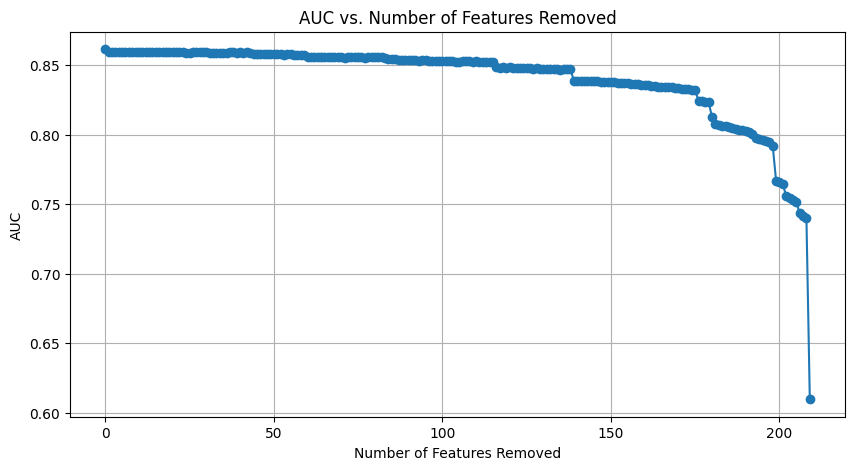

In [ ]:
# Plot graph
t_xgb.plot_auc('log_complete_save.csv')

#### 5. Integration with GUI
- Test how user input will be used against model in app
- List all unique values in dataset and use these as options for the user

In [ ]:
# Take sample from training dataset
sample = X_train.sample(1)
# sample.to_csv("response_template.csv", index=False) #create response template for questionaire

# Predict discharge
t_xgb.predict_discharge(sample)


In [ ]:
# Find all unique values for each column
df_unique_values_dict = {col: df[col].astype(str).unique() for col in df.columns}
df_unique_values_dict

pd.DataFrame(df_unique_values_dict.items()).to_csv("demographics_options.csv", index=False)


#### Harsh's Code

In [ ]:
# This function converts the model prediction into the type of medical facility we should search for

def map_prediction_to_specialty(prediction):

    mapping = {
        "emergency": "hospital",
        "chest_pain": "hospital",
        "skin_rash": "clinic",
        "child_fever": "clinic",
        "general": "clinic",
        "fever": "clinic",
        "breathing_issue": "hospital",
        "pregnancy_issue": "clinic"
    }

    # If the prediction is not in our list we go back to searching for a hospital
    return mapping.get(prediction, "hospital")

In [ ]:
# This function searches for nearby hospitals or clinics

def get_nearby_facilities(predicted_condition, latitude, longitude, radius=5000):

    # First decideing what kind of place we should search for
    specialty = map_prediction_to_specialty(predicted_condition)

    # If the condition looks serious, search hospital Otherwise we search clinics
    if specialty == "hospital":
        search_type = "hospital"
    else:
        search_type = "clinic"

    # This is the search query sent to OpenStreetMap
    overpass_query = f"""
    [out:json];
    (
      node["amenity"="{search_type}"](around:{radius},{latitude},{longitude});
      way["amenity"="{search_type}"](around:{radius},{latitude},{longitude});
      relation["amenity"="{search_type}"](around:{radius},{latitude},{longitude});
    );
    out center;
    """

    url = "https://overpass-api.de/api/interpreter"
    response = requests.get(url, params={"data": overpass_query})

    # If the server does not return normal success, show the message
    if response.status_code != 200:
        print("Request failed with status code:", response.status_code)
        print(response.text[:300])
        return []

    # Trying to read JSON safely
    try:
        data = response.json()
    except Exception:
        print("The server did not return JSON.")
        print(response.text[:300])
        return []

    results = []

    # Collect a few nearby places
    for place in data.get("elements", [])[:5]:
        name = place.get("tags", {}).get("name", "Unknown place")
        lat = place.get("lat", place.get("center", {}).get("lat"))
        lon = place.get("lon", place.get("center", {}).get("lon"))

        results.append({
            "name": name,
            "latitude": lat,
            "longitude": lon
        })

    return results

In [ ]:

predicted_condition = "chest_pain"
latitude = 39.2904
longitude = -76.6122

# geting nearby facilities
results = get_nearby_facilities(predicted_condition, latitude, longitude)

# createing structured response
api_response = {
    "predicted_condition": predicted_condition,
    "recommended_facility_type": map_prediction_to_specialty(predicted_condition),
    "nearby_facilities": results
}

api_response

In [ ]:

predicted_condition = "chest_pain"
latitude = 39.2904
longitude = -76.6122

# smaller radius makes the free API more stable
results = get_nearby_facilities(predicted_condition, latitude, longitude, radius=2000)

# createing structured response
api_response = {
    "predicted_condition": predicted_condition,
    "recommended_facility_type": map_prediction_to_specialty(predicted_condition),
    "nearby_facilities": results
}

api_response

In [ ]:
import requests
import math
import pandas as pd

def map_prediction_to_specialty(prediction):
    mapping = {
        "chest_pain": ["cardiology", "hospital"],
        "skin_rash": ["dermatology", "clinic"],
        "child_fever": ["pediatrics", "clinic"],
        "pregnancy_issue": ["obgyn", "clinic"],
        "breathing_issue": ["pulmonology", "hospital"],
        "emergency": ["hospital"],
        "general": ["clinic"]
    }
    return mapping.get(prediction, ["hospital"])

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radius of Earth in kilometers

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return round(R * c, 2)


def get_amenity_types_for_specialty(specialty):
    specialty = specialty.lower()

    if specialty == "hospital":
        return ["hospital"]
    elif specialty == "clinic":
        return ["clinic", "doctors"]
    else:
        # For specialty searches like cardiology or dermatologywe look in nearby clinics, doctors, and hospitals first.
        return ["clinic", "doctors", "hospital"]

def get_nearby_facilities(predicted_condition, latitude, longitude, radius=5000):
    specialties = map_prediction_to_specialty(predicted_condition)
    results = []
    seen = set()

    for specialty in specialties:
        amenity_types = get_amenity_types_for_specialty(specialty)

        # Building one Overpass query for all useful amenity types
        query_parts = []
        for amenity in amenity_types:
            query_parts.append(f'node["amenity"="{amenity}"](around:{radius},{latitude},{longitude});')
            query_parts.append(f'way["amenity"="{amenity}"](around:{radius},{latitude},{longitude});')
            query_parts.append(f'relation["amenity"="{amenity}"](around:{radius},{latitude},{longitude});')

        overpass_query = f"""
        [out:json][timeout:25];
        (
          {" ".join(query_parts)}
        );
        out center tags;
        """

        url = "https://overpass-api.de/api/interpreter"
        response = requests.get(url, params={"data": overpass_query})

        # If the free server is busy or fails, just skip this specialty
        if response.status_code != 200:
            continue

        try:
            data = response.json()
        except Exception:
            continue

        for place in data.get("elements", []):
            tags = place.get("tags", {})
            name = tags.get("name", "Unknown place")

            lat = place.get("lat", place.get("center", {}).get("lat"))
            lon = place.get("lon", place.get("center", {}).get("lon"))

            # Skip bad records with missing coordinates
            if lat is None or lon is None:
                continue

            amenity = tags.get("amenity", "unknown")

            # Building searchable text from name and tags
            searchable_text = " ".join([
                name,
                tags.get("healthcare", ""),
                tags.get("description", ""),
                tags.get("speciality", ""),
                tags.get("specialty", ""),
                tags.get("department", ""),
                tags.get("operator", "")
            ]).lower()

            if specialty not in ["hospital", "clinic"]:
                if specialty.lower() not in searchable_text and amenity != "hospital":
                    continue

            # Avoiding duplicates using name + coordinates
            unique_key = (name, round(lat, 5), round(lon, 5))
            if unique_key in seen:
                continue
            seen.add(unique_key)

            distance_km = calculate_distance(latitude, longitude, lat, lon)

            results.append({
                "name": name,
                "facility_type": amenity,
                "matched_specialty": specialty,
                "latitude": lat,
                "longitude": lon,
                "distance_km": distance_km,
                "maps_link": f"https://www.google.com/maps/search/?api=1&query={lat},{lon}"
            })

    # Sorting  places so the nearest ones appear first
    results = sorted(results, key=lambda x: x["distance_km"])

    # Returning only the top 10 places
    return results[:10]

predicted_condition = "chest_pain"
latitude = 39.2904
longitude = -76.6122

# Runing the recommendation search
results = get_nearby_facilities(predicted_condition, latitude, longitude, radius=3000)
api_response = {
    "predicted_condition": predicted_condition,
    "recommended_specialties": map_prediction_to_specialty(predicted_condition),
    "nearby_facilities": results
}
print(api_response)

if results:
    display(pd.DataFrame(results))
else:
    print("No facilities found for this search.")

#####Further Work:
> How can we boost the F1 Score???  FEATURE ENGINEERING

> Feature selection ->  Which features can be removed to improve efficiency?